# Import Libraray

In [478]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [479]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Load And Read Dataset

In [480]:
df=pd.read_csv('/content/drive/MyDrive/Crop_recommendation.csv')
df.head()

,Nitrogen,phosphorus,potassium,temperature,humidity,ph,rainfall,label,Unnamed: 8,Unnamed: 9
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,NaN,NaN
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice,NaN,NaN
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice,NaN,NaN
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice,NaN,NaN
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice,NaN,NaN


In [481]:
df.drop(columns=['Unnamed: 8','Unnamed: 9'],inplace=True)

In [482]:
df.head()

,Nitrogen,phosphorus,potassium,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [483]:
df.shape

(2200, 8)

In [484]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Nitrogen     2200 non-null   int64  
 1   phosphorus   2200 non-null   int64  
 2   potassium    2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


In [485]:
df.isnull().sum()

,0
Nitrogen,0
phosphorus,0
potassium,0
temperature,0
humidity,0
ph,0
rainfall,0
label,0


In [486]:
df.duplicated().sum()

np.int64(0)

In [487]:
df.describe()

,Nitrogen,phosphorus,potassium,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


# Apply Median() in Nitrogen Column

In [488]:
df['Nitrogen'].median()

37.0

In [489]:
df['Nitrogen'] = df['Nitrogen'].replace(0, df['Nitrogen'].median())

In [490]:
df['Nitrogen'].describe()

,Nitrogen
count,2200.000000
mean,51.005909
std,36.517956
min,1.000000
25%,22.000000
50%,37.000000
75%,84.250000
max,140.000000


In [491]:
df['label'].value_counts()

,count
label,
rice,100
maize,100
chickpea,100
kidneybeans,100
pigeonpeas,100
mothbeans,100
mungbean,100
blackgram,100
lentil,100


# Check All Column of Unique Value

In [492]:
df['ph'].unique()

array([6.50298529, 7.03809636, 7.84020714, ..., 6.36260785, 6.75879255,
       6.77983261])

In [493]:
df['rainfall'].unique()

array([202.9355362, 226.6555374, 263.9642476, ..., 173.3228386,
       127.1752928, 140.9370415])

In [494]:
df['humidity'].unique()

array([82.00274423, 80.31964408, 82.3207629 , ..., 67.22512329,
       52.12739421, 60.39647474])

In [495]:
df['temperature'].unique()

array([20.87974371, 21.77046169, 23.00445915, ..., 24.13179691,
       26.2724184 , 23.60301571])

In [496]:
df['Nitrogen'].unique()

array([ 90,  85,  60,  74,  78,  69,  94,  89,  68,  91,  93,  77,  88,
        76,  67,  83,  98,  66,  97,  84,  73,  92,  95,  99,  63,  62,
        64,  82,  79,  65,  75,  71,  72,  70,  86,  61,  81,  80, 100,
        87,  96,  40,  23,  39,  22,  36,  32,  58,  59,  42,  28,  43,
        27,  50,  25,  31,  26,  54,  57,  49,  46,  38,  35,  52,  44,
        24,  29,  20,  56,  37,  51,  41,  34,  30,  33,  47,  53,  45,
        48,  13,   2,  17,  12,   6,  10,  19,  11,  18,  21,  16,   9,
         1,   7,   8,   3,   4,   5,  14,  15,  55, 105, 108, 118, 101,
       106, 109, 117, 114, 110, 112, 111, 102, 116, 119, 107, 104, 103,
       120, 113, 115, 133, 136, 126, 121, 129, 122, 140, 131, 135, 123,
       125, 139, 132, 127, 130, 134])

In [497]:
df['phosphorus'].unique()

array([ 42,  58,  55,  35,  37,  53,  54,  46,  56,  50,  48,  38,  45,
        40,  59,  41,  47,  49,  51,  57,  39,  43,  44,  60,  52,  36,
        72,  67,  73,  70,  62,  74,  66,  63,  71,  78,  80,  68,  65,
        77,  76,  79,  61,  64,  69,  75,  24,  18,  26,  27,  25,  21,
        30,  11,   5,  10,   7,  20,  22,  15,  23,   8,  16,  29,  17,
         6,  19,  13,   9,  14,  28,  94,  95,  92,  89,  88,  87,  85,
        86,  83,  91,  81,  84,  90,  82,  93,  33,  31,  34,  32, 130,
       144, 123, 125, 131, 140, 122, 134, 145, 139, 141, 138, 136, 132,
       133, 121, 126, 120, 142, 135, 129, 128, 137, 127, 124, 143,  12])

In [498]:
df['potassium'].unique()

array([ 43,  41,  44,  40,  42,  38,  36,  37,  39,  35,  45,  16,  17,
        21,  20,  19,  25,  22,  15,  18,  23,  24,  77,  84,  85,  81,
        75,  79,  76,  83,  78,  80,  82,  46,  50,  53,  54,  49,  55,
        52,  47,  48,  51,  27,  31,  32,  34,  33,  30,  28,  29,  26,
       195, 204, 205, 196, 198, 197, 203, 201, 202, 199, 200,  12,  13,
         6,   9,  10,  14,   8,   7,   5,  11])

# DATA Visualization

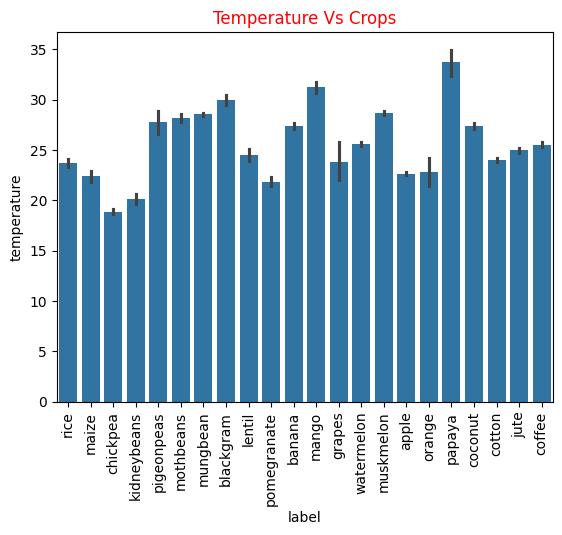

In [499]:
sns.barplot(x='label',y='temperature',data=df)
plt.title('Temperature Vs Crops',color='red')
plt.xticks(rotation='vertical')
plt.show()

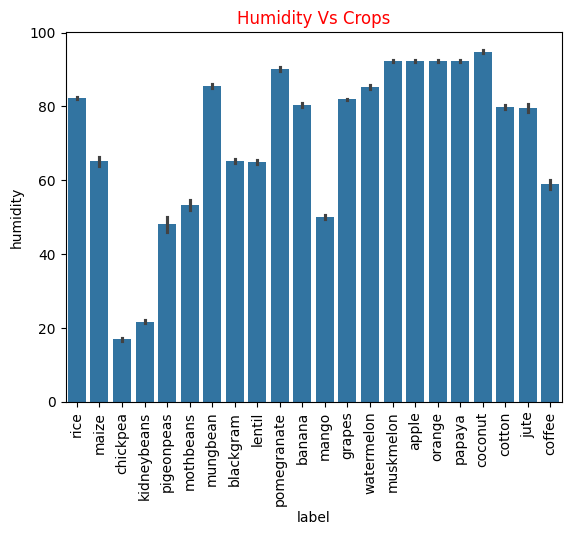

In [500]:
sns.barplot(x='label',y='humidity',data=df)
plt.title('Humidity Vs Crops',color='red')
plt.xticks(rotation='vertical')
plt.show()

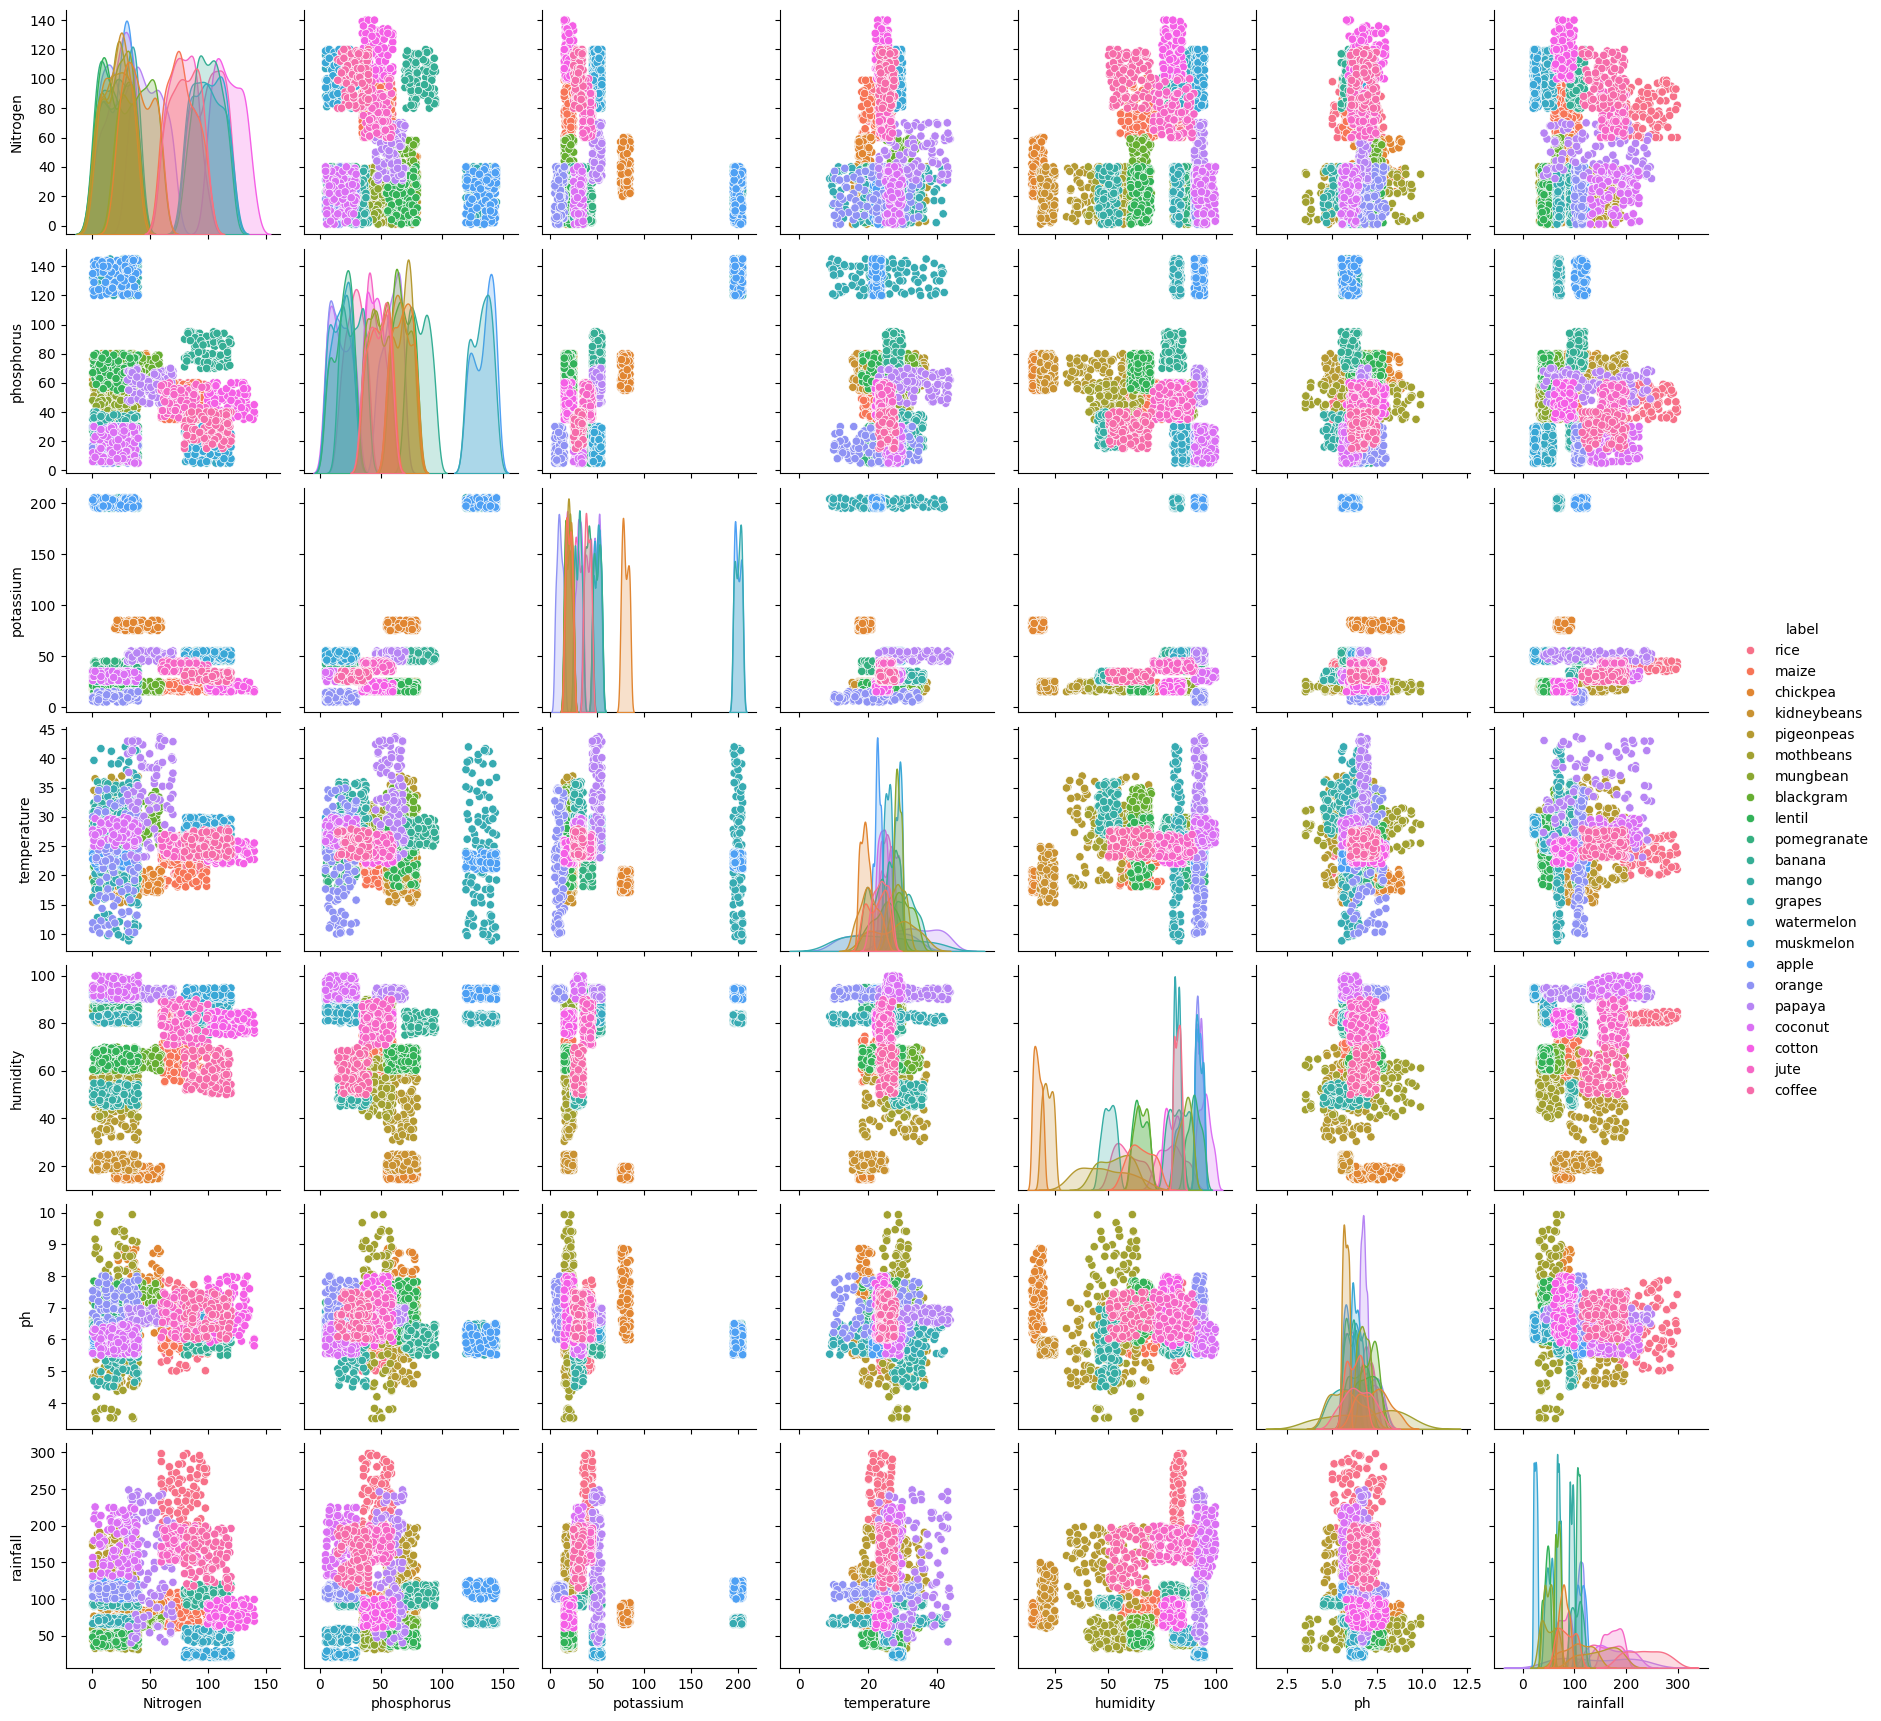

In [501]:
sns.pairplot(df,hue='label')
plt.show()

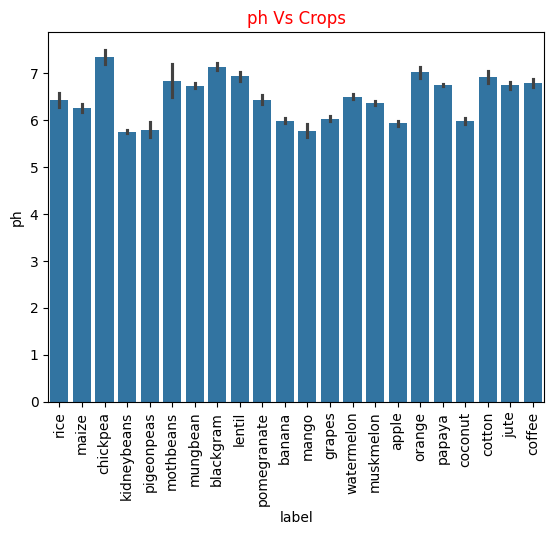

In [502]:
sns.barplot(x='label',y='ph',data=df)
plt.title('ph Vs Crops',color='red')
plt.xticks(rotation='vertical')
plt.show()

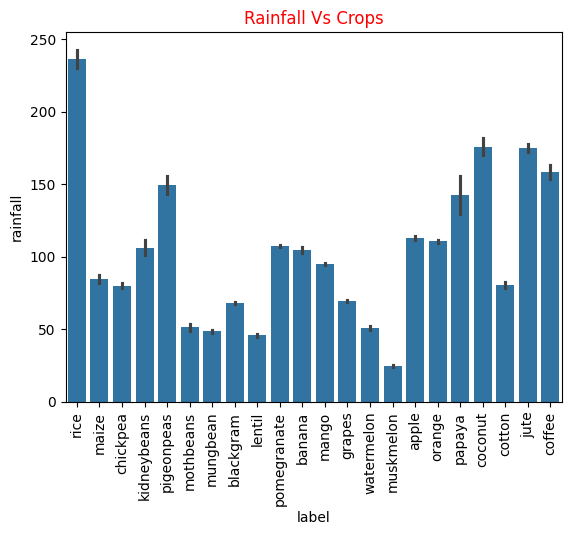

In [503]:
sns.barplot(x='label',y='rainfall',data=df)
plt.title('Rainfall Vs Crops',color='red')
plt.xticks(rotation='vertical')
plt.show()

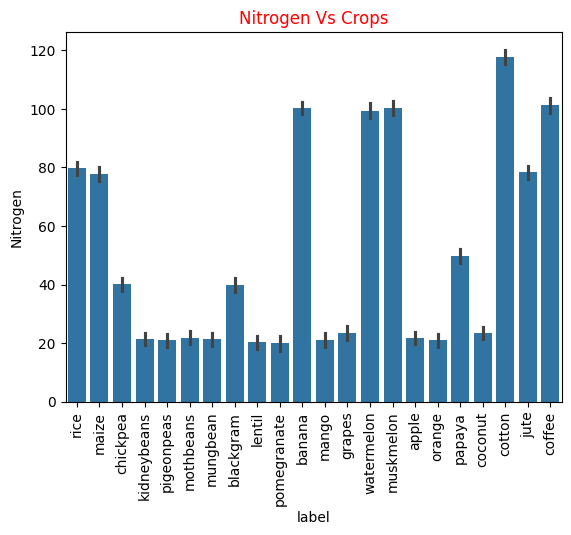

In [504]:
sns.barplot(x='label',y='Nitrogen',data=df)
plt.title('Nitrogen Vs Crops',color='red')
plt.xticks(rotation='vertical')
plt.show()

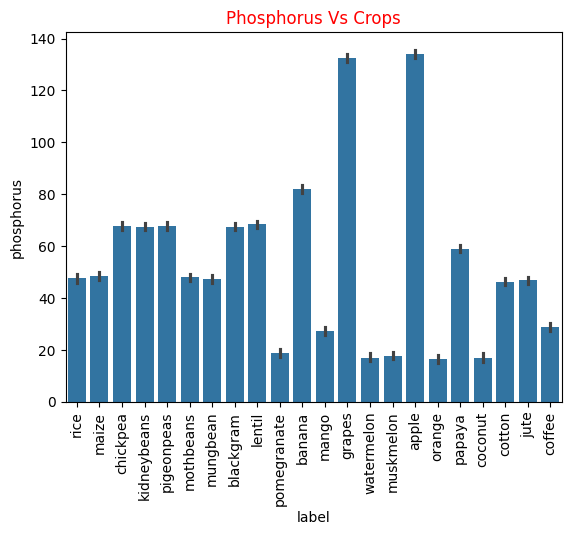

In [505]:
sns.barplot(x='label',y='phosphorus',data=df)
plt.title('Phosphorus Vs Crops',color='red')
plt.xticks(rotation='vertical')
plt.show()

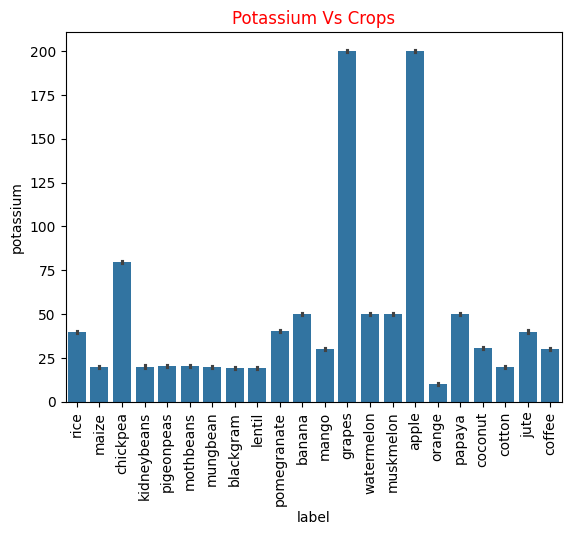

In [506]:
sns.barplot(x='label',y='potassium',data=df)
plt.title('Potassium Vs Crops',color='red')
plt.xticks(rotation='vertical')
plt.show()

# Data Processing and Encoding

In [507]:
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.compose import make_column_transformer
from sklearn.pipeline import Pipeline

# Split X and Y

In [508]:
x=df.drop(columns=['label'])
y=df['label']

# Train Test Split

In [509]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

# Label Encoding

In [510]:
le=LabelEncoder()
le.fit(df['label'])

LabelEncoder()

In [511]:
df['label']=le.transform(df['label'])

In [512]:
df['label'].value_counts()

,count
label,
20,100
11,100
3,100
9,100
18,100
13,100
14,100
2,100
10,100


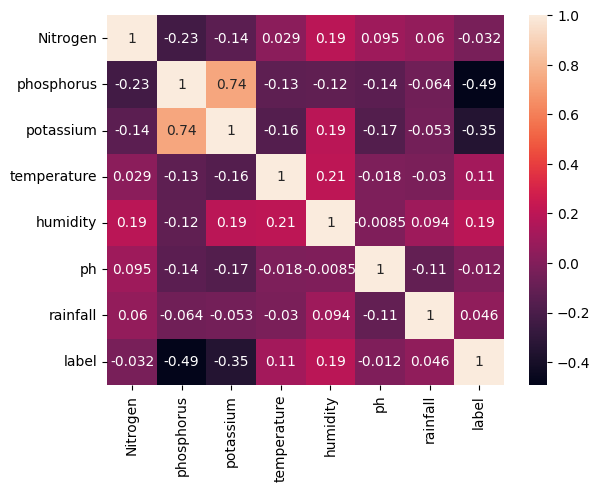

In [513]:
sns.heatmap(df.corr(),annot=True)
plt.show()

# Standardization

In [514]:
st=StandardScaler()
st.fit(x_train,y_train)

StandardScaler()

In [515]:
#column_trans=make_column_transformer((StandardScaler(),['temperature','humidity','ph','rainfall','Nitrogen','phosphorus','potassium']),remainder='passthrough')

In [516]:
#column_trans

In [517]:
#x_train_transform=column_trans.fit_transform(x_train)
#x_test_transform=column_trans.transform(x_test)

# Import All Classification Model

In [518]:

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

In [519]:
from sklearn.metrics import accuracy_score,f1_score,precision_score,recall_score,classification_report

In [520]:
from sklearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer

# Apply LogisticRegression Model and Pipeline With Test Evaluation

In [534]:
step1=make_column_transformer((StandardScaler(),['temperature','humidity','ph','rainfall','Nitrogen','phosphorus','potassium']),
                                     remainder='passthrough')

step2=LogisticRegression()

pipe=make_pipeline(step1,step2)
pipe.fit(x_train,y_train)


y_pred=pipe.predict(x_test)

print('accuracy score',accuracy_score(y_test,y_pred))
print('f1 score',f1_score(y_test,y_pred,average='weighted'))
print('precision score',precision_score(y_test,y_pred,average='weighted'))
print('recall score',recall_score(y_test,y_pred,average='weighted'))
print(classification_report(y_test,y_pred))


accuracy score 0.9613636363636363
f1 score 0.9613309077163119
precision score 0.9622522011559445
recall score 0.9613636363636363
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        23
      banana       1.00      1.00      1.00        21
   blackgram       0.86      0.95      0.90        20
    chickpea       1.00      1.00      1.00        26
     coconut       1.00      1.00      1.00        27
      coffee       0.94      1.00      0.97        17
      cotton       0.94      1.00      0.97        17
      grapes       1.00      1.00      1.00        14
        jute       0.83      0.87      0.85        23
 kidneybeans       0.95      0.95      0.95        20
      lentil       0.83      0.91      0.87        11
       maize       1.00      0.95      0.98        21
       mango       1.00      1.00      1.00        19
   mothbeans       1.00      0.92      0.96        24
    mungbean       1.00      1.00      1.00        19
   mus

# Apply DecisionTreeClassifier Model and Pipeline With Test Evaluation

In [522]:
step1=make_column_transformer((StandardScaler(),['temperature','humidity','ph','rainfall','Nitrogen','phosphorus','potassium']),
                                     remainder='passthrough')

step2=DecisionTreeClassifier()

pipe=make_pipeline(step1,step2)
pipe.fit(x_train,y_train)


y_pred=pipe.predict(x_test)

print('accuracy score',accuracy_score(y_test,y_pred))
print('f1 score',f1_score(y_test,y_pred,average='weighted'))
print('precision score',precision_score(y_test,y_pred,average='weighted'))
print('recall score',recall_score(y_test,y_pred,average='weighted'))
print(classification_report(y_test,y_pred))

accuracy score 0.9886363636363636
f1 score 0.988595068964984
precision score 0.9889971139971141
recall score 0.9886363636363636
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        23
      banana       1.00      1.00      1.00        21
   blackgram       0.95      1.00      0.98        20
    chickpea       1.00      1.00      1.00        26
     coconut       1.00      1.00      1.00        27
      coffee       1.00      1.00      1.00        17
      cotton       1.00      1.00      1.00        17
      grapes       1.00      1.00      1.00        14
        jute       0.92      0.96      0.94        23
 kidneybeans       1.00      1.00      1.00        20
      lentil       0.92      1.00      0.96        11
       maize       1.00      1.00      1.00        21
       mango       1.00      1.00      1.00        19
   mothbeans       1.00      0.92      0.96        24
    mungbean       1.00      1.00      1.00        19
   musk

# Apply KNeighborsClassifier Model and Pipeline With Test Evaluation

In [523]:
step1=make_column_transformer((StandardScaler(),['temperature','humidity','ph','rainfall','Nitrogen','phosphorus','potassium']),
                                     remainder='passthrough')

step2=KNeighborsClassifier()

pipe=make_pipeline(step1,step2)
pipe.fit(x_train,y_train)


y_pred=pipe.predict(x_test)

print('accuracy score',accuracy_score(y_test,y_pred))
print('f1 score',f1_score(y_test,y_pred,average='weighted'))
print('precision score',precision_score(y_test,y_pred,average='weighted'))
print('recall score',recall_score(y_test,y_pred,average='weighted'))
print(classification_report(y_test,y_pred))

accuracy score 0.9568181818181818
f1 score 0.9567492608232794
precision score 0.9628976143584398
recall score 0.9568181818181818
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        23
      banana       1.00      1.00      1.00        21
   blackgram       0.95      0.95      0.95        20
    chickpea       1.00      1.00      1.00        26
     coconut       1.00      1.00      1.00        27
      coffee       0.94      1.00      0.97        17
      cotton       0.89      1.00      0.94        17
      grapes       1.00      1.00      1.00        14
        jute       0.81      0.96      0.88        23
 kidneybeans       0.91      1.00      0.95        20
      lentil       0.69      1.00      0.81        11
       maize       1.00      0.90      0.95        21
       mango       0.90      1.00      0.95        19
   mothbeans       1.00      0.83      0.91        24
    mungbean       1.00      1.00      1.00        19
   mus

# Apply RandomForestClassifier Model and Pipeline With Test Evaluation



In [535]:
step1=make_column_transformer((StandardScaler(),['temperature','humidity','ph','rainfall','Nitrogen','phosphorus','potassium']),
                                     remainder='passthrough')

step2=RandomForestClassifier()

pipe=make_pipeline(step1,step2)
pipe.fit(x_train,y_train)


y_pred=pipe.predict(x_test)

print('accuracy score',accuracy_score(y_test,y_pred))
print('f1 score',f1_score(y_test,y_pred,average='weighted'))
print('precision score',precision_score(y_test,y_pred,average='weighted'))
print('recall score',recall_score(y_test,y_pred,average='weighted'))
print(classification_report(y_test,y_pred))

accuracy score 0.9931818181818182
f1 score 0.9931754816901672
precision score 0.9937348484848485
recall score 0.9931818181818182
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        23
      banana       1.00      1.00      1.00        21
   blackgram       1.00      1.00      1.00        20
    chickpea       1.00      1.00      1.00        26
     coconut       1.00      1.00      1.00        27
      coffee       1.00      1.00      1.00        17
      cotton       1.00      1.00      1.00        17
      grapes       1.00      1.00      1.00        14
        jute       0.92      1.00      0.96        23
 kidneybeans       1.00      1.00      1.00        20
      lentil       0.92      1.00      0.96        11
       maize       1.00      1.00      1.00        21
       mango       1.00      1.00      1.00        19
   mothbeans       1.00      0.96      0.98        24
    mungbean       1.00      1.00      1.00        19
   mus

# Check the Scores of RandomForestClassifier To Evaluate Model Fitting

In [525]:
rf=RandomForestClassifier()
rf.fit(x_train,y_train)

RandomForestClassifier()

In [526]:
print(rf.score(x_test,y_test)*100)
print(rf.score(x_train,y_train)*100)

99.31818181818181
100.0


In [527]:
x_train.columns

Index(['Nitrogen', 'phosphorus', 'potassium', 'temperature', 'humidity', 'ph',
       'rainfall'],
      dtype='object')

# Test the Prediction

In [528]:
pipe.predict(pd.DataFrame(columns=['Nitrogen','phosphorus','potassium','temperature','humidity','ph','rainfall'],data=np.array([90,42,43,20.879744,82.002744,6.502985,202.935536]).reshape(1,7)))

array(['rice'], dtype=object)

# Apply SVC Model and Pipeline With Test Evaluation



In [529]:
step1=make_column_transformer((StandardScaler(),['temperature','humidity','ph','rainfall','Nitrogen','phosphorus','potassium']),
                                     remainder='passthrough')

step2=SVC(kernel='linear')

pipe=make_pipeline(step1,step2)
pipe.fit(x_train,y_train)


y_pred=pipe.predict(x_test)

print('accuracy score',accuracy_score(y_test,y_pred))
print('f1 score',f1_score(y_test,y_pred,average='weighted'))
print('precision score',precision_score(y_test,y_pred,average='weighted'))
print('recall score',recall_score(y_test,y_pred,average='weighted'))
print(classification_report(y_test,y_pred))

accuracy score 0.975
f1 score 0.97482003349344
precision score 0.976575523592569
recall score 0.975
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        23
      banana       1.00      1.00      1.00        21
   blackgram       0.91      1.00      0.95        20
    chickpea       1.00      1.00      1.00        26
     coconut       1.00      1.00      1.00        27
      coffee       1.00      1.00      1.00        17
      cotton       0.94      1.00      0.97        17
      grapes       1.00      1.00      1.00        14
        jute       0.85      0.96      0.90        23
 kidneybeans       0.91      1.00      0.95        20
      lentil       0.91      0.91      0.91        11
       maize       1.00      0.95      0.98        21
       mango       1.00      1.00      1.00        19
   mothbeans       1.00      0.96      0.98        24
    mungbean       1.00      1.00      1.00        19
   muskmelon       1.00      1.00  

# Import Pickle


In [531]:
import pickle

# Save the Model

In [532]:
pickle.dump(pipe,open('pipe.pkl','wb'))
pickle.dump(df,open('df.pkl','wb'))

In [533]:
df.head()

,Nitrogen,phosphorus,potassium,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,20
1,85,58,41,21.770462,80.319644,7.038096,226.655537,20
2,60,55,44,23.004459,82.320763,7.840207,263.964248,20
3,74,35,40,26.491096,80.158363,6.980401,242.864034,20
4,78,42,42,20.130175,81.604873,7.628473,262.717340,20
